In [61]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [62]:
df = pd.read_csv("../data/churn.csv")

In [63]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [64]:
df.shape

(7043, 33)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [66]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [67]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

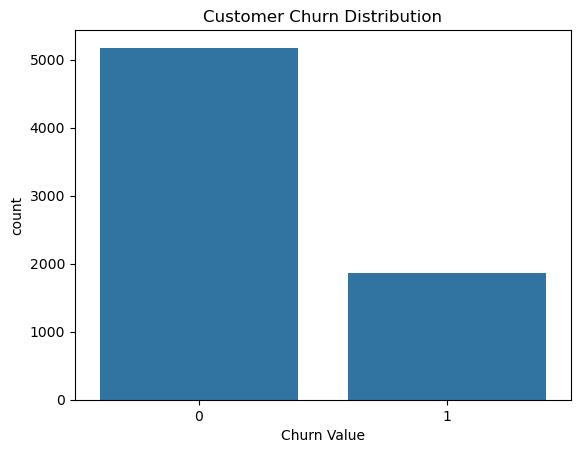

In [68]:
sns.countplot(x="Churn Value", data=df)
plt.title("Customer Churn Distribution")
plt.show()

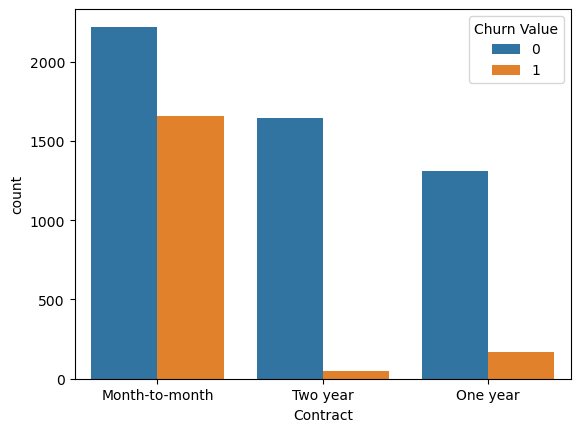

In [69]:
sns.countplot(x="Contract", hue="Churn Value", data=df)
plt.show()

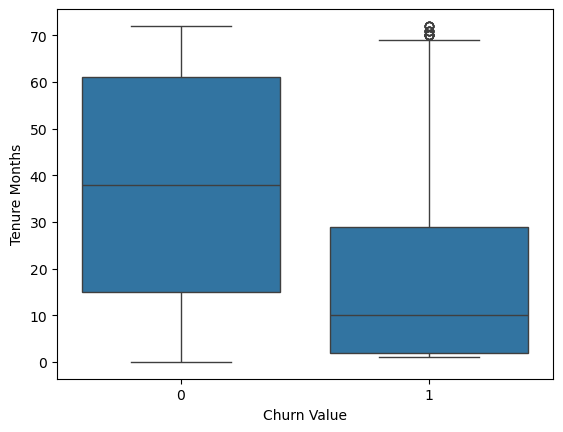

In [70]:
sns.boxplot(x="Churn Value", y="Tenure Months", data=df)
plt.show()

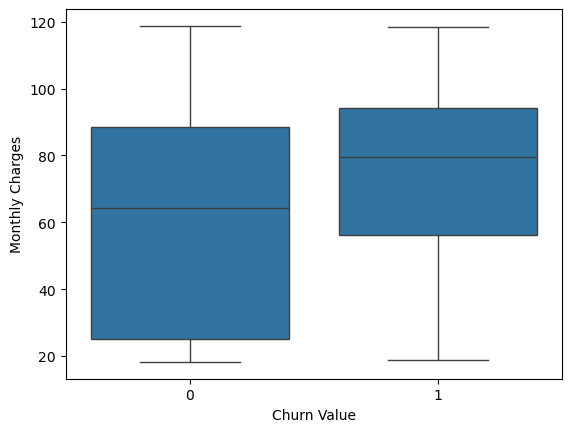

In [71]:
sns.boxplot(x="Churn Value", y="Monthly Charges", data=df)
plt.show()

In [72]:
df = df.drop(columns=[
    "CustomerID","Count","Country","State","City","Zip Code",
    "Lat Long","Latitude","Longitude",
    "Churn Label","Churn Score","CLTV","Churn Reason"
])

In [73]:
df = df.rename(columns={"Churn Value":"Churn"})

In [74]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7720\1588731996.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)


In [75]:
df = pd.get_dummies(df, drop_first=True)

In [76]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [78]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [79]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [80]:
accuracy_score(y_test, lr_pred)

0.8019872249822569

In [81]:
confusion_matrix(y_test, lr_pred)

array([[900, 109],
       [170, 230]], dtype=int64)

In [82]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

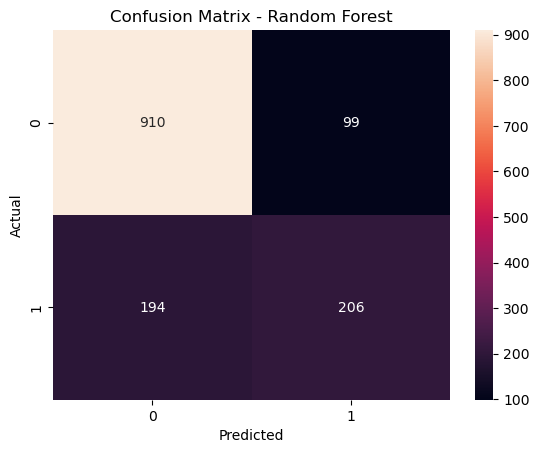

In [83]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [84]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.68      0.52      0.58       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [85]:
accuracy_score(y_test, rf_pred)

0.7920511000709723

In [86]:
confusion_matrix(y_test, rf_pred)

array([[910,  99],
       [194, 206]], dtype=int64)

In [87]:
importance = pd.Series(
rf.feature_importances_,
index=X.columns
).sort_values(ascending=False)

In [88]:
importance.head(10)

Total Charges                      0.190676
Tenure Months                      0.172489
Monthly Charges                    0.167198
Payment Method_Electronic check    0.039318
Dependents_Yes                     0.035169
Internet Service_Fiber optic       0.034031
Contract_Two year                  0.030297
Gender_Male                        0.027246
Partner_Yes                        0.026040
Paperless Billing_Yes              0.025584
dtype: float64

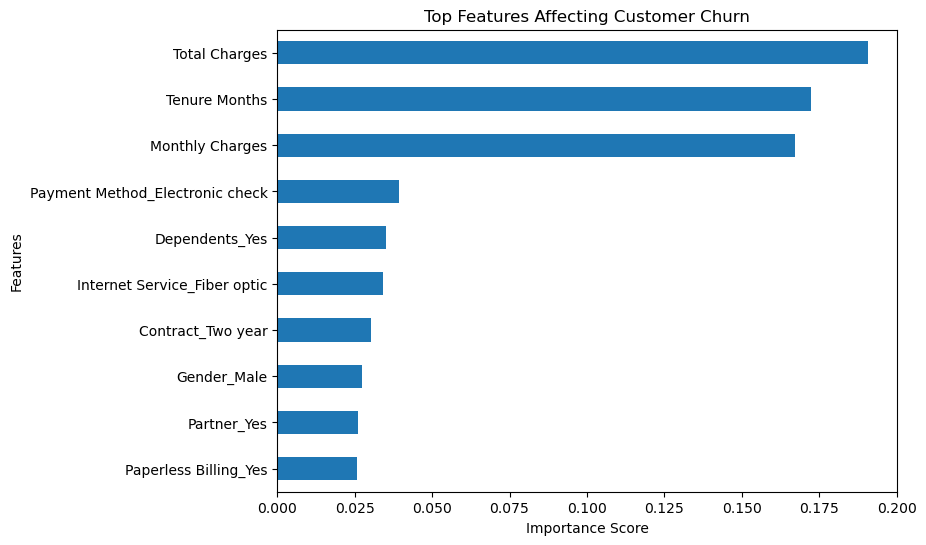

In [89]:
importance.head(10).plot(kind="barh", figsize=(8,6))

plt.title("Top Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [90]:
import pickle

pickle.dump(rf, open("churn_model.pkl","wb"))

Business Insights

1. Customers with high total charges and monthly charges are more likely to churn.
2. Customers with low tenure tend to leave the service early.
3. Payment method such as electronic check shows higher churn behaviour.
4. Service features like fiber optic internet and paperless billing also contribute to churn patterns.

These insights can help telecom companies identify high-risk customers and implement retention strategies such as loyalty offers or contract upgrades.